In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from shapely.geometry import mapping
from matplotlib import pyplot


# -----------------------------
# Inputs
# -----------------------------
polygons_path = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\Exports\BasePolys.shp"
nlcd_path = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\Rasters\NLCD_CONUS_5070.tif"
out_csv = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\NLCD\NLCD.csv"

# -----------------------------
# NLCD classes
# -----------------------------
nlcd_classes = {
    11: "Open Water",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    81: "Pasture/Hay",
    82: "Cultivated Crops",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
}

nodata_val = 255

# -----------------------------
# Logger
# -----------------------------
def log(msg):
    print(f"[{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

# -----------------------------
# Main Processing
# -----------------------------
log("Loading shapefile")
gdf = gpd.read_file(polygons_path)

# Force ROW_ID to be the dataframe index
# gdf = gdf.set_index("ROW_ID", drop=False)

# gdf.explore()

In [ ]:

# # Safety check
# assert gdf["ROW_ID"].is_unique, "ROW_ID must be unique"

# if "Square_Met" not in gdf.columns:
#     gdf["Square_Met"] = None

# log("Fixing invalid geometries")
# gdf["geometry"] = gdf["geometry"].buffer(0)

# total_polys = len(gdf)
# log(f"Total polygons: {total_polys}")

# results = []

# log("Opening raster")
# with rasterio.open(nlcd_path) as src:

#     for i, (row_id, row) in enumerate(gdf.iterrows(), start=1):

#         geom = row.geometry
#         square_met = row["Square_Met"]

#         try:
#             minx, miny, maxx, maxy = geom.bounds
#             window = src.window(minx, miny, maxx, maxy)

#             width = max(int(np.ceil(window.width)), 1)
#             height = max(int(np.ceil(window.height)), 1)

#             safe_window = Window(
#                 int(window.col_off),
#                 int(window.row_off),
#                 width,
#                 height
#             )

#             data = src.read(1, window=safe_window)

#             mask = rasterize(
#                 [(mapping(geom), 1)],
#                 out_shape=data.shape,
#                 transform=src.window_transform(safe_window),
#                 fill=0,
#                 all_touched=True,
#                 dtype="uint8",
#             )

#             captured_pixels = np.count_nonzero(mask)

#             if captured_pixels == 0:
#                 results.append((row_id, square_met, -1, "No Data", 0))
#                 continue

#             values = data[mask == 1]
#             values = values[values != nodata_val]

#             if len(values) == 0:
#                 results.append((row_id, square_met, -1, "No Data", captured_pixels))
#                 continue

#             counts = np.bincount(values.astype(np.int32))
#             mode_val = np.argmax(counts)
#             mode_class = nlcd_classes.get(mode_val, "Unknown")

#             results.append((row_id, square_met, int(mode_val), mode_class, int(captured_pixels)))

#         except Exception:
#             results.append((row_id, square_met, -1, "Error", 0))

#         # Progress update every 25k polygons
#         if i % 25000 == 0 or i == total_polys:
#             pct = (i / total_polys) * 100
#             log(f"Progress: {pct:.1f}% ({i}/{total_polys})")

# log("Writing CSV")

# df_out = pd.DataFrame(
#     results,
#     columns=["ROW_ID", "Square_Met", "NLCD_Code", "NLCD_Class", "Pixels_Captured"]
# )

# df_out.to_csv(out_csv, index=False)

# log("Done")

In [ ]:

# -----------------------------
# Main Processing
# -----------------------------
log("Loading shapefile")
gdf = gpd.read_file(polygons_path)

# Force ROW_ID to be the dataframe index
gdf = gdf.set_index("ROW_ID", drop=False)

# Safety check
assert gdf["ROW_ID"].is_unique, "ROW_ID must be unique"

if "Square_Met" not in gdf.columns:
    gdf["Square_Met"] = None

log("Fixing invalid geometries")
gdf["geometry"] = gdf["geometry"].buffer(0)

total_polys = len(gdf)
log(f"Total polygons: {total_polys}")

results = []



In [ ]:

log("Opening raster")
with rasterio.open(nlcd_path) as src:

    for i, (row_id, row) in enumerate(gdf.iterrows(), start=1):

        geom = row.geometry
        square_met = row["Square_Met"]

        try:
            minx, miny, maxx, maxy = geom.bounds
            window = src.window(minx, miny, maxx, maxy)

            width = max(int(np.ceil(window.width)), 1)
            height = max(int(np.ceil(window.height)), 1)

            safe_window = Window(
                int(window.col_off),
                int(window.row_off),
                width,
                height
            )

            data = src.read(1, window=safe_window)

            mask = rasterize(
                [(mapping(geom), 1)],
                out_shape=data.shape,
                transform=src.window_transform(safe_window),
                fill=0,
                all_touched=True,
                dtype="uint8",
            )

            captured_pixels = np.count_nonzero(mask)

            if captured_pixels == 0:
                results.append((row_id, square_met, -1, "No Data", 0))
                continue

            values = data[mask == 1]
            values = values[values != nodata_val]

            if len(values) == 0:
                results.append((row_id, square_met, -1, "No Data", captured_pixels))
                continue

            counts = np.bincount(values.astype(np.int32))
            mode_val = np.argmax(counts)
            mode_class = nlcd_classes.get(mode_val, "Unknown")

            results.append((row_id, square_met, int(mode_val), mode_class, int(captured_pixels)))

        except Exception:
            results.append((row_id, square_met, -1, "Exception", 0))

        # Progress update every 25k polygons
        if i % 25000 == 0 or i == total_polys:
            pct = (i / total_polys) * 100
            log(f"Progress: {pct:.1f}% ({i}/{total_polys})")

log("Writing CSV")

df_out = pd.DataFrame(
    results,
    columns=["ROW_ID", "Square_Met", "NLCD_Code", "NLCD_Class", "Pixels_Captured"]
)

df_out.to_csv(out_csv, index=False)

log("Done")

In [1]:

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from rasterio.plot import show
import numpy as np
import pandas as pd
from shapely.geometry import mapping

# -----------------------------
# Inputs
# -----------------------------
polygons_path = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\Exports\BasePolys.shp"
nlcd_path = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\Rasters\NLCD_CONUS_5070_clipped.tif"
out_csv = r"C:\Users\KevinWilliams\Documents\Source Files\CVG ROW Solar\NLCD\NLCD.csv"

# -----------------------------
# Logger
# # -----------------------------
def log(msg):
    print(f"[{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")

# -----------------------------
# Load polygons
# -----------------------------
# log("Loading shapefile")
gdf = gpd.read_file(polygons_path)

# Ensure ROW_ID_OG exists and set as index
if "ROW_ID" not in gdf.columns:
    gdf["ROW_ID"] = gdf.index
gdf.set_index("ROW_ID", inplace=True)

#log("Fixing invalid geometries")
#gdf["geometry"] = gdf["geometry"].buffer(0)

# -----------------------------
# Open NLCD raster
# -----------------------------
# log("Opening NLCD raster")
src = rasterio.open(nlcd_path)
nodata_val = 0



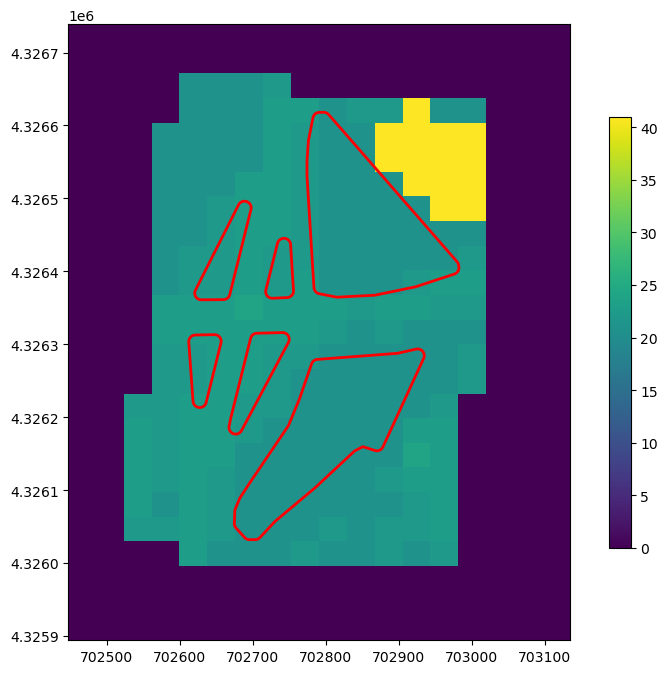

In [21]:
import matplotlib.pyplot as plt
with rasterio.open(nlcd_path) as src:
    fig, ax = plt.subplots(figsize=(10,8))
    image_axes = show(src.read(1), transform=src.transform, ax=ax, cmap="viridis")
    image_object = image_axes.get_images()[0]
    cbar = fig.colorbar(image_object, ax=ax, shrink=0.7)
    gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    plt.show()

In [2]:



# -----------------------------
# Print CRS info
# -----------------------------
log(f"Polygon CRS: {gdf.crs}")
log(f"Raster CRS: {src.crs}")

# -----------------------------
# NLCD classes mapping
# -----------------------------
nlcd_classes = {
    11: "Open Water",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    81: "Pasture/Hay",
    82: "Cultivated Crops",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
}

# -----------------------------
# Function to get majority NLCD value
# -----------------------------
def majority_nlcd(geom):
    """Return mode NLCD code and class for a polygon safely."""
    minx, miny, maxx, maxy = geom.bounds

    # Create raster window
    window = src.window(minx, miny, maxx, maxy)

    # Safe window: ensure width/height >= 1
    width = max(int(np.ceil(window.width)), 1)
    height = max(int(np.ceil(window.height)), 1)
    safe_window = Window(window.col_off, window.row_off, width, height)

    # Read raster data
    data = src.read(1)

    # Rasterize polygon
    mask = rasterize(
        [(mapping(geom), 1)],
        out_shape=data.shape,
        transform=src.window_transform(safe_window),
        fill=0,
        all_touched=True,
        dtype="uint8",
    )

    captured_pixels = np.count_nonzero(mask)
    if captured_pixels == 0:
        return None, None, 0

    values = data[mask == 1]
    values = values[values != nodata_val]  # ignore nodata
    if len(values) == 0:
        return None, None, captured_pixels

    counts = np.bincount(values)
    mode_val = np.argmax(counts)
    mode_class = nlcd_classes.get(mode_val, "Unknown")

    return mode_val, mode_class, captured_pixels

# -----------------------------
# Process polygons with progress
# -----------------------------
results = []
total_polys = len(gdf)
log(f"Processing {total_polys} polygons")

for i, (idx, row) in enumerate(gdf.iterrows(), start=1):
    geom = row.geometry
    code, cls, pixels = majority_nlcd(geom)

    results.append({
        "ROW_ID": idx,
        "NLCD_Code": code if code is not None else -1,
        "NLCD_Class": cls if cls is not None else "No Data",
        "Pixels_Captured": pixels,
    })

    # Progress updates every 5% or last polygon
    if i % max(1, total_polys // 20) == 0 or i == total_polys:
        pct = (i / total_polys) * 100
        print(f"[{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}] Progress: {pct:.1f}% ({i}/{total_polys})")

# -----------------------------
# Write CSV
# -----------------------------
df_out = pd.DataFrame(results)
df_out.to_csv(out_csv, index=False)
log(f"Writing CSV to {out_csv}")
log("Done")

[2026-07-30 09:39:52] Polygon CRS: EPSG:26916
[2026-07-30 09:39:52] Raster CRS: EPSG:26916
[2026-07-30 09:39:52] Processing 6 polygons
[2026-07-30 09:39:59] Progress: 16.7% (1/6)


KeyboardInterrupt: 